<a href="https://colab.research.google.com/github/acastellanos-ie/NLP-MBDS-PT/blob/main/transfer_learning_and_fine_tuning/day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Colab Configuration

**Execute this steps to configure the Google Colab environment in order to execute this notebook. It is not required if you are executing it locally and you have properly configured your local environment according to what explained in the Github Repository.**

In [1]:
# @title Colab Setup

repository_name = "NLP-MBDS-PT"
repository_url = 'https://github.com/acastellanos-ie/' + repository_name

print("### Cloning the Repository ###")
! git clone $repository_url
print()

print("### Installing requirements ###")
! pip3 install -Uqqr $repository_name/transfer_learning_and_fine_tuning/requirements.txt
! pip install --upgrade pyarrow datasets

%cd $repository_name/transfer_learning_and_fine_tuning

### Cloning the Repository ###
Cloning into 'NLP-MBDS-PT'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 70 (delta 30), reused 2 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 705.83 KiB | 5.93 MiB/s, done.
Resolving deltas: 100% (30/30), done.

### Installing requirements ###
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.2 MB/s eta 0:00:00
/content/NLP-MBDS-PT/transfer_learning_and_fine_tuning


Everything is set up properly! You can now move on to the practice code.

I do recommend you to restart the environment at this point to ensure that Google Colab is aware of the installed packages and their configuration (see image below).

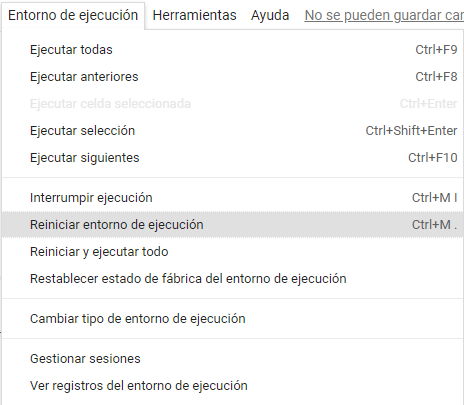

Ensure that you have the GPU runtime activated:

![](https://miro.medium.com/max/3006/1*vOkqNhJNl1204kOhqq59zA.png)

Now you have everything you need to execute the code in Colab

In [2]:
from IPython.core.display import display, HTML

import warnings
warnings.filterwarnings('ignore')

# Matplotlib conf
import matplotlib.pyplot as plt
%matplotlib inline

# Seaborn conf
import seaborn as sns
sns.set_palette(sns.color_palette("seismic"))

import sys

import pandas as pd
import numpy as np
import operator
import string
import nltk

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer

from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

from sklearn.naive_bayes import MultinomialNB


# Introduction


In this practice we will address a text classification problem: we will try to predict whether a given tweet is about a real disaster or not. In particular I propose you the scenario presented at the [Real or Not? NLP with Disaster Tweets Kaggle Competition.](https://www.kaggle.com/c/nlp-getting-started/leaderboard).

To that, I am going to follow 2 different approaches:
- Apply traditional text classification methodologies based on "simple" Machine Learning models
- Apply state-of-the-art deep learning models

I have decided to give Deep Learning a try by applying the classification models explained in class.
However, the dataset we have at our disposal includes "only" 65K documents. We all know that to apply Deep Learning you need tons of data and weeks of training, right?

Well, this in not true, or at least, this is not anymore completely true thanks to **Transfer Learning**. If you are training a huge model from scratch, you do need a lot of data and GPU time. Lucklily for us, these huge models are already pre-trained for many languages using large datasets (e.g. Wikipedia). All we have to do is to adapt these models to our particular domain. 65K documents are not enough to learn English, but they are definitely enough to learn the nuances of the dataset.

Cool, now we have a model adapted to the specific language in my dataset but the business case was to create a classifier. Why am I even doing all of this? In the traditional ML methodologies we were feeding our algorithms with a rather simple representation of our textual contents (The TF-IDF vectors). Now, thanks to the fine-tune pre-trained models, I can feed my classifier with a much more detailed and accurate representation of the input textual content. Therefore, it should be easier to the classifier to better categorize the textual content.


Summing up, my strategy will be:

1.   Use a pre-trained English Language Model trained over a large dataset as starting point.
2.   Adapt this language model to our domain. To that end, I will retrain the model to learn the particular aspects of the dataset.
3.   Create a Machine Learning Classifier on top of the dataset language model


**Side note: I have trained this model on Google Colab to be able to use a GPU.For this reason, I did not include anything about the configuration of the GPU or the installation of the required libraries. To execute it I do recommend you to update it to Google Colab**


# STEP 1: Loading and preprocessing the data

Before starting to play with the DeepLearning models we need to read, inspect and clean (if needed) the dataset.

The dataset is provided in 2 different CSV files (one for training and another one for test)

In [3]:
training_df = pd.read_csv('nlp_disaster/data/train.csv', sep=',', index_col=0)
training_df = training_df.sample(frac=1).reset_index(drop=True)
training_df.head()

,keyword,location,text,target
0,detonation,NaN,Ignition Knock (Detonation) Sensor-Senso Stand...,0
1,destroy,NaN,@engineermataRAI ate mataas kc rating..but the...,0
2,collision,Colorado,#Colorado #News Motorcyclist bicyclist injured...,1
3,explosion,NaN,@colinhoffman29 I hope he does. And I hope you...,1
4,wild%20fires,"Cedar Island, Clinton CT 06413",DEEP crew to help with California wild fires h...,1


As you can see, the training set contains the dependent variable (1 or 0, real or not) as well as some independent variables: the actual text of the tweet and some of the metadata related

In [4]:
test_df = pd.read_csv('nlp_disaster/data/test.csv', sep=',', index_col=0)
test_df.head()

,keyword,location,text
id,,,
0,NaN,NaN,Just happened a terrible car crash
2,NaN,NaN,"Heard about #earthquake is different cities, s..."
3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


The test set contains the same independent variables, but no label whatsoever. This is the common scenario proposed by Kaggle. You get a training set to create your models and then you have to use these models to predict over the test set.

## Inspecting the data

In this step I will try to make sense of the kind of data that we have.

### Class distribution

The first thing I will do is to inspect the distribution of the target variable to check if we have an imbalace problem

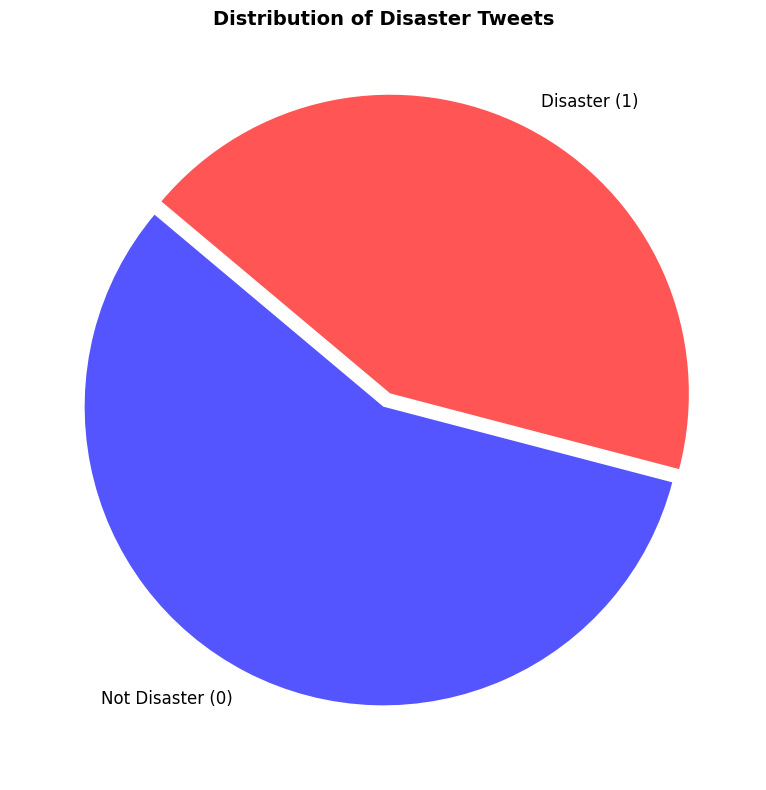

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data calculation
target_counts = training_df['target'].value_counts()
labels = ['Not Disaster (0)', 'Disaster (1)']
colors = sns.color_palette("seismic", n_colors=2)

# Create figure with only the Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(target_counts, labels=labels, startangle=140,
        colors=colors, explode=(0, 0.05), textprops={'fontsize': 12})

plt.title('Distribution of Disaster Tweets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

As seen in the figure, There are a slight difference between the number of tweets at each class but nothing to worry about.

### Metadata

Beyond the textual content, we have 2 pieces of information:

 - keyword: the keyword used as query to retrieve the tweets
 - location: Location of the user posting the tweet

Regarding the **keywords**, some of them can be strongly related to a given category, but they can be also highly ambiguous as you can see in the following figure (I used the code in this kernel to create it: https://www.kaggle.com/grantgasser/eda-naive-bayes-bert-glove-fasttext-nn).


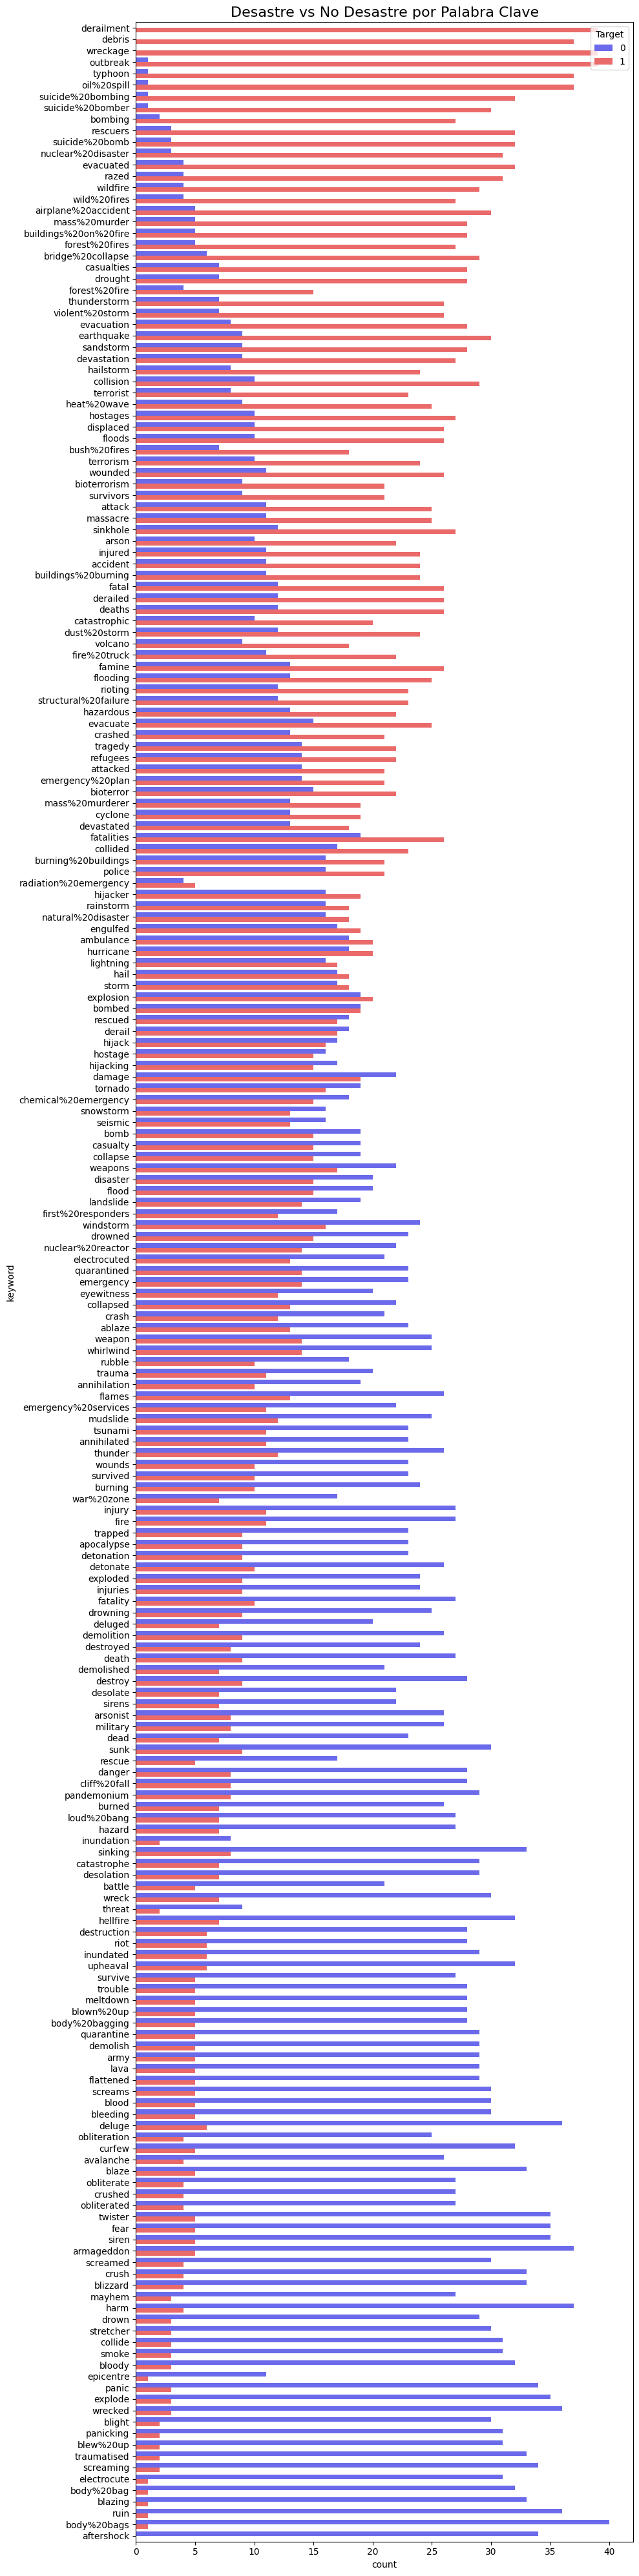

In [6]:
# Visualización simple de palabras clave relacionadas con el objetivo
df_train = training_df.copy()
df_test = test_df.copy()

# Calculamos la media del target por palabra clave para ordenarlas
kw_order = df_train.groupby('keyword')['target'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 40))
sns.countplot(y='keyword', hue='target', data=df_train, order=kw_order, palette='seismic')

plt.title('Desastre vs No Desastre por Palabra Clave', fontsize=16)
plt.legend(title='Target', loc='upper right')
plt.tight_layout()
plt.show()

Given that the keywords are already included in the textual content (the tweets have been retrieved because they include some of the keywords), I have decided to discard this information as I expect that we can learn the importance of the keywords as individual tokens in the textual content.

A future work that I recommend you to consider is to create a classifier just based on the keywords and compare its performance to the most advanced ones that I am proposing in this solution. If a Classifier simply based on the keywords is good enough, perhaps you can stick to it, thus avoiding the complexities of dealing with textual information.

Let's analyze the **location**.

The first aspect to consider is that it has many null values

In [7]:
print("% of null columns =", (len(training_df.location) - training_df.location.count())/len(training_df))

% of null columns = 0.33272034677525286


This is a common features of any twitter dataset. For privacy reasons, many people prefer to keep their locations to themselves. This could change in the case of a disaster, you may want to share your location to give a better understanding of the disaster. I am not going to focus on this idea and, again, I encourage you to test it and check if you can further improve your models.

Summing up, I will only focus on the textual information (`text` column) of the dataset.

### Textual Data

At this point we have to options:

- Focus just on the actual textual content by applying the NLP methodologies addressed in class for text classification
- Increase the information in the dataset by feature-engineer some new features derived from the textual content (e.g., lenght of the tweets, how many stopwords in the tweets, how many urls...).
    
To further analyze if this idea makes sense, I have used the code in this kernel (https://www.kaggle.com/gunesevitan/nlp-with-disaster-tweets-eda-cleaning-and-bert) to create some of these features and plot them against the target variable

In [8]:
nltk.download('stopwords')

# word_count
df_train['word_count'] = df_train['text'].apply(lambda x: len(str(x).split()))
df_test['word_count'] = df_test['text'].apply(lambda x: len(str(x).split()))

# unique_word_count
df_train['unique_word_count'] = df_train['text'].apply(lambda x: len(set(str(x).split())))
df_test['unique_word_count'] = df_test['text'].apply(lambda x: len(set(str(x).split())))

# stop_word_count
df_train['stop_word_count'] = df_train['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in nltk.corpus.stopwords.words("english")]))
df_test['stop_word_count'] = df_test['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in nltk.corpus.stopwords.words("english")]))

# url_count
df_train['url_count'] = df_train['text'].apply(lambda x: len([w for w in str(x).lower().split() if 'http' in w or 'https' in w]))
df_test['url_count'] = df_test['text'].apply(lambda x: len([w for w in str(x).lower().split() if 'http' in w or 'https' in w]))

# mean_word_length
df_train['mean_word_length'] = df_train['text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))
df_test['mean_word_length'] = df_test['text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

# char_count
df_train['char_count'] = df_train['text'].apply(lambda x: len(str(x)))
df_test['char_count'] = df_test['text'].apply(lambda x: len(str(x)))

# punctuation_count
df_train['punctuation_count'] = df_train['text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))
df_test['punctuation_count'] = df_test['text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

# hashtag_count
df_train['hashtag_count'] = df_train['text'].apply(lambda x: len([c for c in str(x) if c == '#']))
df_test['hashtag_count'] = df_test['text'].apply(lambda x: len([c for c in str(x) if c == '#']))

# mention_count
df_train['mention_count'] = df_train['text'].apply(lambda x: len([c for c in str(x) if c == '@']))
df_test['mention_count'] = df_test['text'].apply(lambda x: len([c for c in str(x) if c == '@']))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


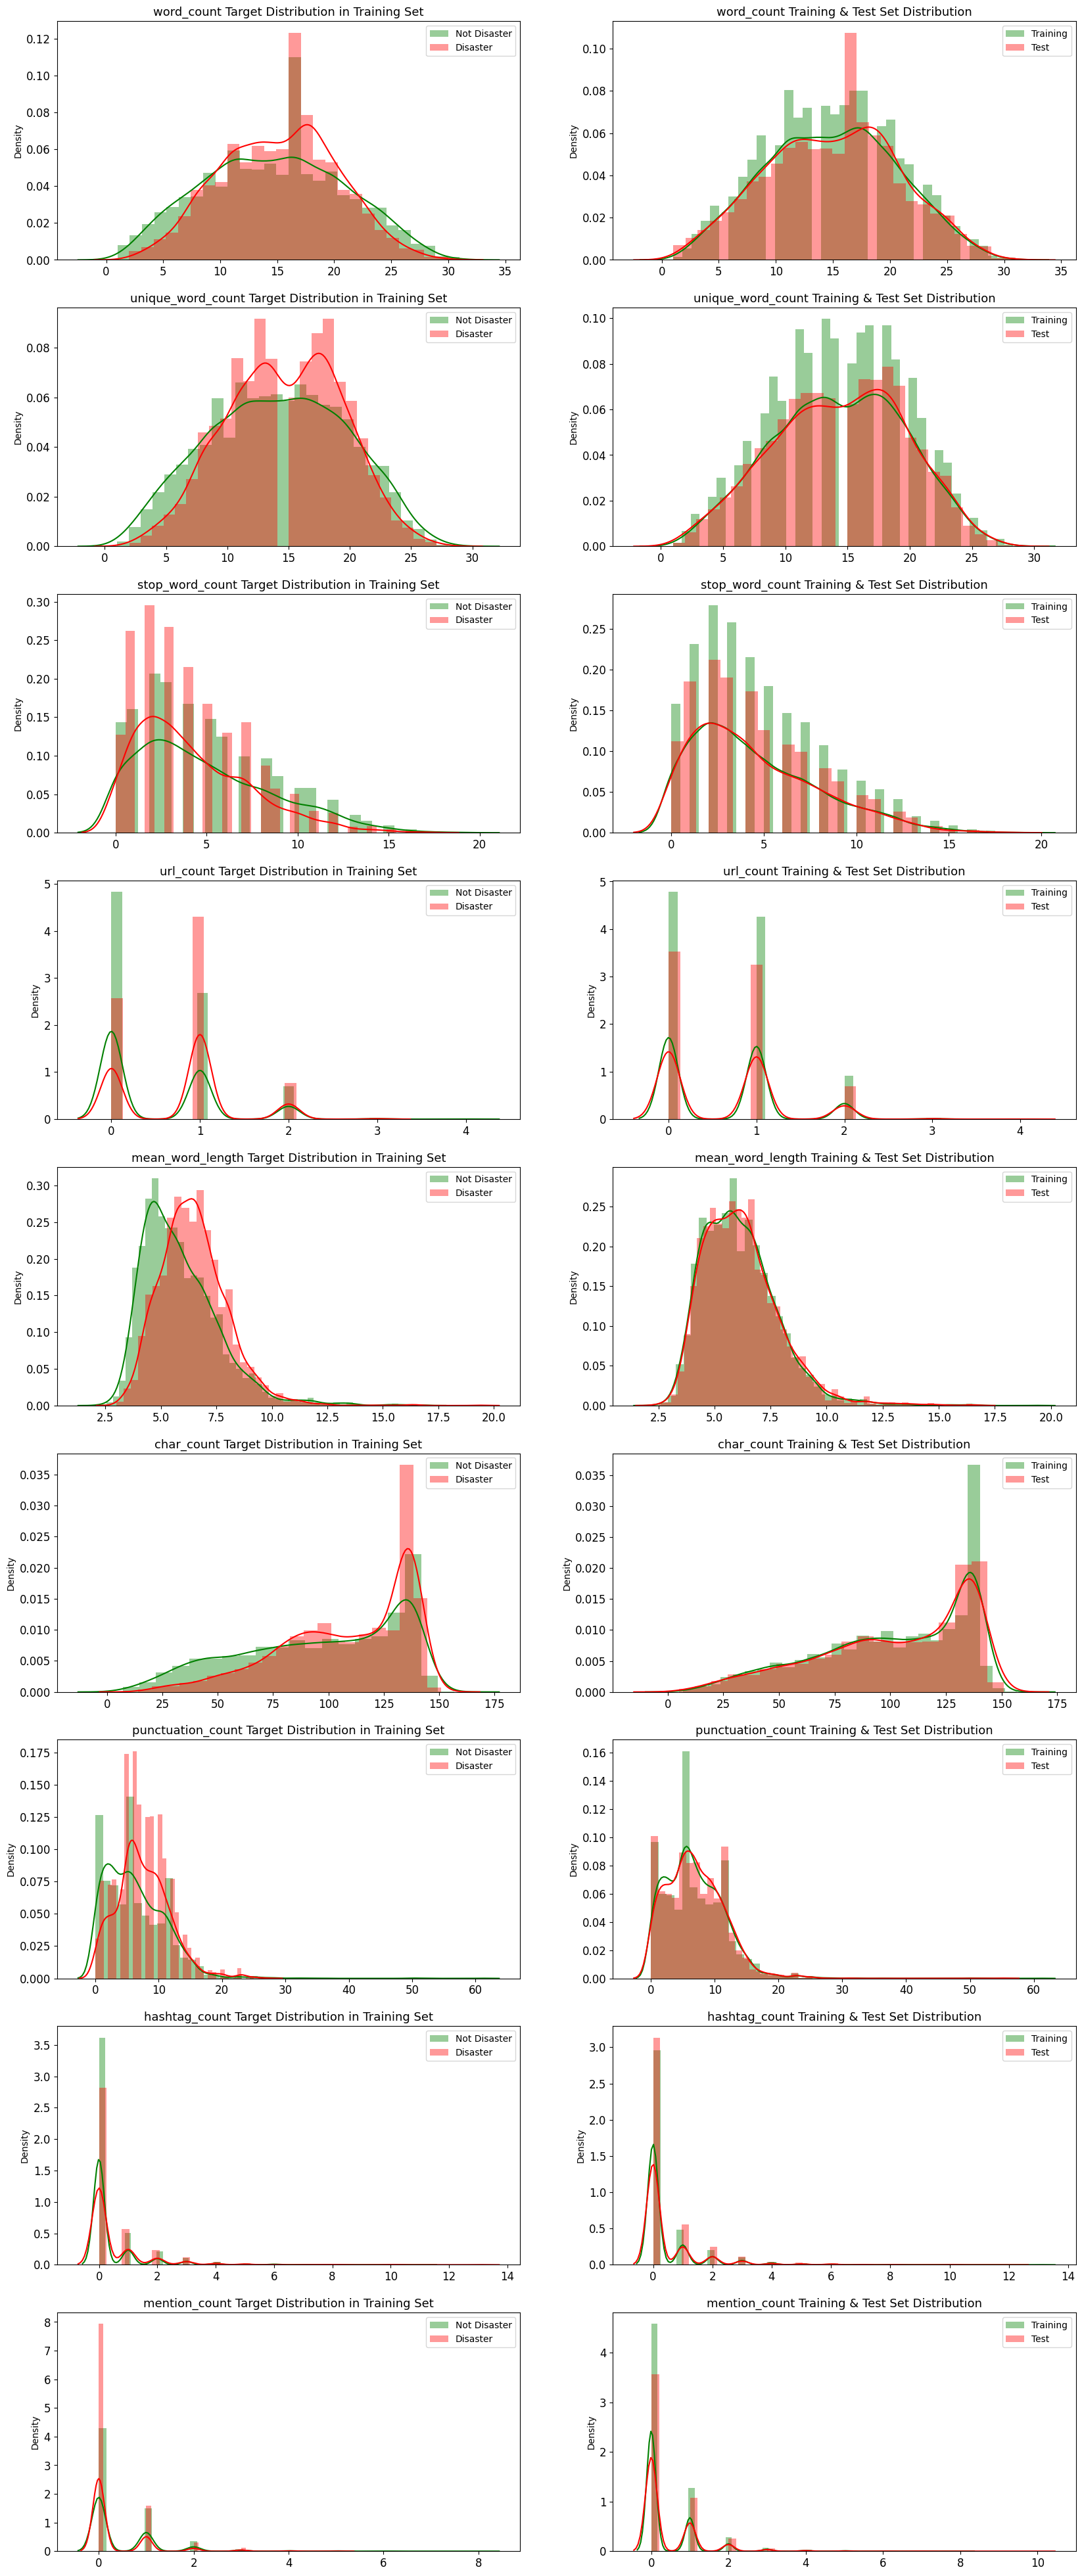

In [9]:
import warnings
warnings.filterwarnings('ignore')

METAFEATURES = ['word_count', 'unique_word_count', 'stop_word_count', 'url_count', 'mean_word_length',
                'char_count', 'punctuation_count', 'hashtag_count', 'mention_count']
DISASTER_TWEETS = df_train['target'] == 1

fig, axes = plt.subplots(ncols=2, nrows=len(METAFEATURES), figsize=(20, 50), dpi=100)

for i, feature in enumerate(METAFEATURES):
    sns.distplot(df_train.loc[~DISASTER_TWEETS][feature], label='Not Disaster', ax=axes[i][0], color='green')
    sns.distplot(df_train.loc[DISASTER_TWEETS][feature], label='Disaster', ax=axes[i][0], color='red')

    sns.distplot(df_train[feature], label='Training', ax=axes[i][1], color='green')
    sns.distplot(df_test[feature], label='Test', ax=axes[i][1], color='red')

    for j in range(2):
        axes[i][j].set_xlabel('')
        axes[i][j].tick_params(axis='x', labelsize=12)
        axes[i][j].tick_params(axis='y', labelsize=12)
        axes[i][j].legend()

    axes[i][0].set_title(f'{feature} Target Distribution in Training Set', fontsize=13)
    axes[i][1].set_title(f'{feature} Training & Test Set Distribution', fontsize=13)

plt.show()

These figures shows the comparison between the class `disaster` and `not disaster` in the training set (on the left) and the comparison between the training and test datasets (on the right) for the different derived features.

In general terms, they do not provide any interesting insight. The distribution of all of these new features are basically the same in both classes and datasets. Consequently, I do not expect them to be of any help for creating the classification models (or at least I do not expect their impact to be large enough to motivate their use). At a closer inspection, the length of the tweets seems to be slightly different between the classes. In this sense, you can test this aspect by including these new feature in your models and check if you can improve your final model.

Anyhow, I have decided to just use the textual information without any new feature to create my models

### Text Processing and Data Preparation

Let's try a basic Natural Language Pre-processing:

 - Extract English Words
 - Stem words to avoid over counting same meaning words
 - Removing stop words


I will join training and test datasets to apply the same process to both

In [10]:
dataset = pd.concat([training_df,test_df], sort=True)

To encapsulate this process and facilitate its application, we create a function `process_text` which encloses all the text processing

In [11]:
from nltk.stem import *
from nltk.corpus import stopwords

import re

def process_text(raw_text):

    letters_only = re.sub("[^a-zA-Z]", " ",raw_text)
    words = letters_only.lower().split()

    stops = set(stopwords.words("english"))
    not_stop_words = [w for w in words if not w in stops]

    stemmer = PorterStemmer()
    stemmed = [stemmer.stem(word) for word in not_stop_words]

    return( " ".join( stemmed ))

We now apply this function to the textual content.
Just in case we need the raw text later, we will create new columns to store the processed text.

In [12]:
dataset['clean_text'] = dataset['text'].apply(lambda x: process_text(x))
dataset.head()

,keyword,location,target,text,clean_text
0,detonation,NaN,0.0,Ignition Knock (Detonation) Sensor-Senso Stand...,ignit knock deton sensor senso standard ks htt...
1,destroy,NaN,0.0,@engineermataRAI ate mataas kc rating..but the...,engineermatarai ate mataa kc rate think like d...
2,collision,Colorado,1.0,#Colorado #News Motorcyclist bicyclist injured...,colorado news motorcyclist bicyclist injur den...
3,explosion,NaN,1.0,@colinhoffman29 I hope he does. And I hope you...,colinhoffman hope hope die explos
4,wild%20fires,"Cedar Island, Clinton CT 06413",1.0,DEEP crew to help with California wild fires h...,deep crew help california wild fire http co qk...


We now split the dataset again for the creation and evaluation of the models into training and test


In [13]:
X_train = dataset[0:len(training_df)][["clean_text"]]
y_train = dataset[0:len(training_df)][["target"]]
X_test = dataset[len(training_df):len(dataset)][["clean_text"]]
y_test = dataset[len(training_df):len(dataset)][["target"]]

# STEP 2: Machine Learning Models

Having cleaned the dataset, we now establish a performance baseline using Bag-of-Words representations and traditional ML classifiers. This step is crucial to define the "performance ceiling" of statistical methods before moving toward Deep Learning.

**Feature Engineering: TF-IDF Vectorization**

We transform the raw text into numerical feature vectors using TF-IDF (Term Frequency-Inverse Document Frequency). Unlike simple word counts, TF-IDF penalizes common stop words and rewards rare, meaningful terms, providing a weighted numerical representation of the documents in a high-dimensional Vector Space Model.

**Traditional Classifiers for Benchmarking**

We evaluate three distinct mathematical approaches to identify the most robust baseline:

- Multinomial Naïve Bayes: A probabilistic model that relies on Bayes' Theorem. It assumes conditional independence between words, which is computationally efficient and surprisingly effective for the short, keyword-heavy nature of Twitter data.
- Support Vector Machines (SVM): A discriminative model that seeks to maximize the margin between classes in high-dimensional space. SVMs are historically the gold standard for text classification due to their ability to handle large feature sets.
- Logistic Regression / MaxEnt: A model that estimates class probabilities without the strict independence assumptions of Naïve Bayes. It is particularly effective at capturing subtle feature interactions.

**Training and Evaluation**

We use GridSearchCV to systematically optimize hyperparameters for each algorithm.



In [14]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, ShuffleSplit

# 1. Cross-Validaton Setup
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
models = [
    ("Naive Bayes", MultinomialNB(), {}),
    ("SVM", SVC(), {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear', 'rbf']}),
    ("MaxEnt", LogisticRegression(), {'clf__C': [0.1, 1, 10], 'clf__penalty': ['l2']})
]

# 2. Classifier Execution
results = {}

for name, clf, params in models:
    # Pipeline with Vectorizacion and Classification
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', clf)
    ])

    grid_search = GridSearchCV(pipeline, param_grid=params, cv=cv, n_jobs=-1, verbose=1)
    grid_search.fit(X_train['clean_text'], y_train['target'])

    results[name] = grid_search.best_score_
    print(f"{name} - Best Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Naive Bayes - Best Score: 0.8007
Fitting 5 folds for each of 6 candidates, totalling 30 fits
SVM - Best Score: 0.8059
Fitting 5 folds for each of 3 candidates, totalling 15 fits
MaxEnt - Best Score: 0.7976


While these models typically achieve respectable performance (around 80% accuracy), they are inherently limited by their "bag-of-words" nature: they ignore word order and lack deep semantic understanding. This benchmark sets the stage for the next phase, where we will implement Transfer Learning and Fine-Tuning using pre-trained Transformer architectures to capture context and surpass this traditional NLP limit.